Epoch 50/200, Loss: 0.336485
Epoch 100/200, Loss: 0.286977
Epoch 150/200, Loss: 0.215970
Epoch 200/200, Loss: 0.159856


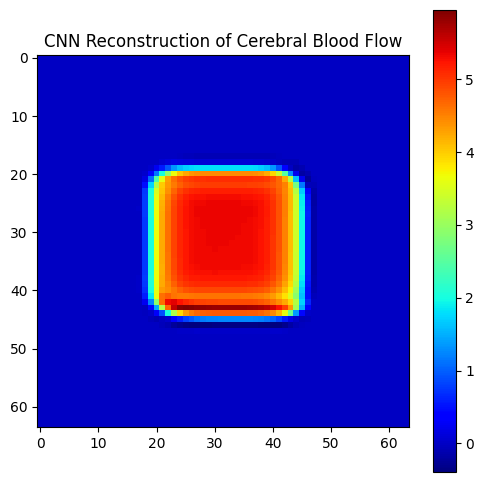

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ====================================
# CNN FLOW RECONSTRUCTION WITH DOWNLOAD
# ====================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import os

# 1️⃣ Create results folder
os.makedirs("results", exist_ok=True)

# 2️⃣ Generate synthetic flow map (simulate ischemic region)
size = 64
flow_true = np.zeros((size, size))
flow_true[20:45, 20:45] = 5  # simulated high-flow region
flow_measured = gaussian_filter(flow_true, sigma=3)  # optical blur simulation

# 3️⃣ Convert to PyTorch tensors
X = torch.tensor(flow_measured, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
Y = torch.tensor(flow_true, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# 4️⃣ Define simple CNN
class ReconNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,16,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,1,3,padding=1)
        )
    def forward(self,x):
        return self.model(x)

net = ReconNet()
optimizer = optim.Adam(net.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# 5️⃣ Training loop
for epoch in range(200):
    optimizer.zero_grad()
    output = net(X)
    loss = loss_fn(output, Y)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/200, Loss: {loss.item():.6f}")

# 6️⃣ Reconstruct and visualize
reconstructed = net(X).detach().numpy()[0,0]

plt.figure(figsize=(6,6))
plt.imshow(reconstructed, cmap='jet')
plt.title("CNN Reconstruction of Cerebral Blood Flow")
plt.colorbar()
plt.savefig("results/cnn_reconstruction.png", dpi=300, bbox_inches='tight')
plt.show()

# 7️⃣ Download the result in Colab
from google.colab import files
files.download("results/cnn_reconstruction.png")